# 6 Pipeline de Random Forest

In [62]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("Laboratorio7_RandomForest")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark listo")

Spark listo


In [63]:
import os

print("Contenido de working_dir:")
print(os.listdir("/opt/app/working_dir/lab7/working_dir"))

Contenido de working_dir:
['constitution.txt', 'lab7', 'nba', 'trump_tweets']


In [64]:
ruta_2025 = "/opt/app/working_dir/lab7/working_dir/lab7/preparado/personas_2025_preparado.parquet"
ruta_2026 = "/opt/app/working_dir/lab7/working_dir/lab7/preparado/personas_2026_preparado.parquet"

df_2025 = spark.read.parquet(ruta_2025)
df_2026 = spark.read.parquet(ruta_2026)

print("2025:" , df_2025.count( ) , "registros" )
print("2026:" , df_2026.count( ) , "registros" )

2025: 53025 registros
2026: 13258 registros


In [65]:
df_2025.select(
    "salario_mensual" ,
    "edad" ,
    
    "antiguedad" ,
    "horas_semanales" ,
    "nivel_educativo" ,
    "categoria_ocupacional" ,
    "dominio"
).show( 10 , truncate = False )

+---------------+----+------------------+---------------+---------------+---------------------+-------+
|salario_mensual|edad|antiguedad        |horas_semanales|nivel_educativo|categoria_ocupacional|dominio|
+---------------+----+------------------+---------------+---------------+---------------------+-------+
|8500.0         |36.0|2.0               |72.0           |3              |2                    |1      |
|3000.0         |47.0|14.0              |60.0           |3              |2                    |2      |
|2000.0         |53.0|15.416666666666666|16.0           |2              |3                    |2      |
|3200.0         |16.0|0.0               |44.0           |3              |2                    |2      |
|3000.0         |20.0|2.4166666666666665|45.0           |4              |2                    |2      |
|1800.0         |53.0|20.5              |45.0           |2              |4                    |2      |
|2300.0         |36.0|6.0               |91.0           |2      

## selección de variables predictoras

In [67]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [68]:
categoricas = [ "nivel_educativo", "categoria_ocupacional", "dominio" ]
numericas = [ "edad", "antiguedad",  "horas_semanales" ]

## codificación de variables categóricas con StringIndexer y OneHotEncoder

In [69]:
indexers = [ StringIndexer( inputCol = columna , outputCol = columna + "_index" , handleInvalid = "keep" )
    for columna in categoricas
]

encoder = OneHotEncoder( inputCols = [columna + "_index" for columna in categoricas], outputCols = [columna + "_ohe" for columna in categoricas] )

## construcción del vector de características

In [70]:
assembler = VectorAssembler( inputCols = numericas + [columna + "_ohe" for columna in categoricas] , outputCol = "features" )

## primera configuración de Random Forest

In [71]:
rf_1 = RandomForestRegressor( featuresCol = "features", labelCol = "salario_mensual" , numTrees = 50 , maxDepth = 5 , seed = 42 )
pipeline_rf_1 = Pipeline(stages = indexers + [encoder , assembler, rf_1] )

In [72]:
modelo_rf_1 = pipeline_rf_1.fit(train_df)

Como primera configuración, realizamos un Random Forest con 50 árboles y una profundidad de 5 con una semilla fija de 42 para garantizar que los resultados sean reproducibles. Como Random Forest no necesita estandarización de las variables predictoras, el vector de características se puede usar sin necesidad de cambios.

In [73]:
pred_rf_1 = modelo_rf_1.transform(val_df)

pred_rf_1.select( "salario_mensual", "prediction" ).show(10)

+---------------+------------------+
|salario_mensual|        prediction|
+---------------+------------------+
|         7500.0| 5376.288202436932|
|         3600.0| 4721.207602110189|
|          800.0| 2130.697570032073|
|         3200.0|  2260.63244881584|
|         3500.0| 3888.587929917166|
|         1800.0|1783.1222783650041|
|         2400.0| 2031.631372034763|
|         2800.0|3295.8196098420985|
|         4000.0| 5125.769949017983|
|         3500.0| 3540.403924604453|
+---------------+------------------+
only showing top 10 rows



### Evaluación de la configuración 1

Evaluamos este modelo con MAE, RMSE y R². Para seleccionar la mejor configuración se utiliza principalmente el RMSE, como indica la guía.

In [74]:
evaluador_mae = RegressionEvaluator( labelCol = "salario_mensual" , predictionCol = "prediction", metricName = "mae" )
evaluador_rmse = RegressionEvaluator( labelCol = "salario_mensual" , predictionCol = "prediction" , metricName = "rmse" )
evaluador_r2 = RegressionEvaluator( labelCol ="salario_mensual", predictionCol= "prediction", metricName= "r2" )

mae_1 = evaluador_mae.evaluate(pred_rf_1)
rmse_1 = evaluador_rmse.evaluate(pred_rf_1)
r2_1 = evaluador_r2.evaluate(pred_rf_1)

print("Random Forest de configuración 1")
print("numTrees = 50")
print("maxDepth = 5")
print("MAE:", mae_1)
print("RMSE:", rmse_1)
print("R²:", r2_1)

Random Forest de configuración 1
numTrees = 50
maxDepth = 5
MAE: 1204.2779109312437
RMSE: 2361.6198755462256
R²: 0.3906166170734362


La primera configuración mostró un MAE de Q1,204.28 y un RMSE de Q2,361.62. El R² fue de 0.3906, con esto podemos decir que el modelo explica el 39.1% de la variación en el salario mensual dentro del conjunto de validación.

## Configuración 2

In [75]:
rf_2 = RandomForestRegressor(
    featuresCol= "features",
    labelCol= "salario_mensual",
    numTrees= 100,
    maxDepth= 10 ,
    seed = 42
)

pipeline_rf_2 = Pipeline( stages = indexers + [encoder, assembler, rf_2] ) 

In [76]:
modelo_rf_2 = pipeline_rf_2.fit(train_df )
pred_rf_2 = modelo_rf_2.transform(val_df)

In [114]:
mae_2 = evaluador_mae.evaluate(pred_rf_2)
rmse_2 = evaluador_rmse.evaluate(pred_rf_2)
r2_2 = evaluador_r2.evaluate(pred_rf_2)

print("Random Forest de configuración 2")
print("numTrees = 100")
print("maxDepth = 10")
print("MAE:", mae_2)
print("RMSE:", rmse_2)
print("R²:", r2_2)

Random Forest de configuración 2
numTrees = 100
maxDepth = 10
MAE: 1075.7349521253716
RMSE: 1981.9272189521275
R²: 0.5280821034681797


Esta segunda configuración mostró un MAE de Q1,127.79, un RMSE de Q2,142.01 y un R² de 0.4987. En comparación con la primera, esta tiene una disminución tanto en MAE como en RMSE y también hay un aumento en el R². Por ende, hay mejora en la predicción del modelo.

Por ende, el mejor pipeline entrenado es la configuración 2 para Random Forest. Esto ya que tiene el menor RMSE y el mejor R².

| configuración | árboles | profundidad | MAE | RMSE | R² |
|---|---:|---:|---:|---:|---:|
| 1 | 50 | 5 | 1204.28 | 2361.62 | 0.3906 |
| 2 | 100 | 10 | 1127.79 | 2142.01 | 0.4987 |


#### Mejor modelo

In [115]:
df_train = df_2025.filter(F.col("periodo_archivo") != "2025T4")
df_val = df_2025.filter(F.col("periodo_archivo") == "2025T4")

print("Entrenamiento:", df_train.count())
print("Validación:", df_val.count())

Entrenamiento: 40361
Validación: 12664


In [116]:
modelo_rf_1 = pipeline_rf_1.fit(df_train)
pred_rf_1 = modelo_rf_1.transform(df_val)

modelo_rf_2 = pipeline_rf_2.fit(df_train)
pred_rf_2 = modelo_rf_2.transform(df_val)

In [117]:
mae_1_correcto = evaluador_mae.evaluate(pred_rf_1)
rmse_1_correcto = evaluador_rmse.evaluate(pred_rf_1)
r2_1_correcto = evaluador_r2.evaluate(pred_rf_1)

mae_2_correcto = evaluador_mae.evaluate(pred_rf_2)
rmse_2_correcto = evaluador_rmse.evaluate(pred_rf_2)
r2_2_correcto = evaluador_r2.evaluate(pred_rf_2)

print("Configuración 1")
print("MAE:", mae_1_correcto)
print("RMSE:", rmse_1_correcto)
print("R²:", r2_1_correcto)

print("\nConfiguración 2")
print("MAE:", mae_2_correcto)
print("RMSE:", rmse_2_correcto)
print("R²:", r2_2_correcto)

Configuración 1
MAE: 1154.6126952094137
RMSE: 2167.728547525951
R²: 0.4354520468139361

Configuración 2
MAE: 1075.7349521253716
RMSE: 1981.9272189521275
R²: 0.5280821034681797


Esta segunda configuración mostró un MAE de Q1,075.73, un RMSE de Q1,981.93 y un R² de 0.5281. En comparación con la primera configuración, se tiene una disminución en el MAE y en el RMSE, además hay un aumento en el R². Por ende, hay mejora en la capacidad de predicción.

Por esta razón, se seleccionó la configuración 2 como el mejor pipeline de Random Forest, ya que obtuvo el menor RMSE de validación y el mayor R².

| configuración | árboles | profundidad | MAE | RMSE | R² |
|---|---:|---:|---:|---:|---:|
| 1 | 50 | 5 | 1154.61 | 2167.73 | 0.4355 |
| 2 | 100 | 10 | 1075.73 | 1981.93 | 0.5281 |

#### comparación con la regresión lineal

| Modelo | MAE | RMSE | R² |
|---|---:|---:|---:|
| Modelo de referencia | 1718.09 | 2871.42 | -0.0025 |
| Regresión lineal | 1240.71 | 2163.75 | 0.4307 |
| Random Forest | 1101.54 | 1954.04 | 0.5357 |

Al comparar ambos modelos sobre el conjunto de prueba de 2026, Random Forest obtuvo mejores resultados que la regresión lineal en las tres métricas utilizadas. Random Forest presentó un MAE de Q1,101.54 y un RMSE de Q1,954.04, mientras que la regresión lineal obtuvo un MAE de Q1,240.71 y un RMSE de Q2,163.75. Esto indica que, en promedio, las predicciones de Random Forest presentaron un menor error.

Además, Random Forest obtuvo un R² de 0.5357, superior al 0.4307 obtenido por la regresión lineal. Por lo tanto, Random Forest logró explicar una mayor parte de la variación observada en el salario mensual.


Random Forest y regresión lineal funcionan diferente. La regresión lineal lo que hace es intentar representar la relación entre las variables predictoras y el salario de forma lineal. Por su parte, Random Forest usa árboles de decisión, es decir, como no es lineal representa relaciones más complejas. Por ello, Random Forest puede reflejar mejores valores cuando la relación entre las variables no sigue un comportamiento lineal.


#### mejor modelo (2)

Seleccionamos la configuración 2 como el mejor modelo de Random Forest debido a que obtuvo el menor RMSE de validación. Este modelo utiliza 100 árboles, una profundidad máxima de 10 y una semilla fija de 42.

In [118]:
mejor_modelo_rf = modelo_rf_2

In [119]:
ruta_modelo_rf = "/opt/app/working_dir/lab7/working_dir/lab7/modelos/random_forest_mejor"
mejor_modelo_rf.write().overwrite().save(ruta_modelo_rf)

print("Modelo guardado en:")
print(ruta_modelo_rf )

Modelo guardado en:
/opt/app/working_dir/lab7/working_dir/lab7/modelos/random_forest_mejor


El mejor modelo de Random Forest se guardó para conservar la configuración seleccionada durante la etapa de validación.

In [120]:
import os
print(os.path.exists(ruta_modelo_rf ) )

True


# 7. Entrenamiento final y evaluación en 2026

Después de seleccionar la mejor configuración de Random Forest utilizando los datos de validación de 2025T4, volvimos a entrenar el pipeline con los registros de 2025.

Luego, el modelo final se evalúa sobre el primer trimestre de 2026.

In [89]:
df_2025_full = df_train.unionByName(df_val)

print("registros usados para entrenamiento final:", df_2025_full.count())

registros usados para entrenamiento final: 53025


### entrenamiento final

Para el entrenamiento final utilizamos los 53,025 registros elegibles de 2025. Se mantuvo la configuración seleccionada anteriormente para Random Forest, con 100 árboles, profundidad máxima de 10 y una semilla fija de 42.

In [90]:
rf_final = RandomForestRegressor(
    featuresCol = "features",
    labelCol = "salario_mensual",
    numTrees= 100,
    maxDepth = 10,
    seed = 42
)

pipeline_rf_final = Pipeline(stages=indexers + [encoder , assembler, rf_final])
modelo_rf_final = pipeline_rf_final.fit(df_2025_full)

### evaluación sobre 2026

El modelo final genera predicciones sobre los datos del primer trimestre de 2026. 

In [91]:
pred_test_rf = modelo_rf_final.transform(df_2026)

In [92]:
mae_rf_test = evaluador_mae.evaluate(pred_test_rf)
rmse_rf_test = evaluador_rmse.evaluate(pred_test_rf)
r2_rf_test = evaluador_r2.evaluate( pred_test_rf )

print("random forest test para 2026")
print("MAE:" , mae_rf_test)
print("RMSE:", rmse_rf_test)
print("R²:", r2_rf_test)

[Stage 518:>                                                        (0 + 1) / 1]

random forest test para 2026
MAE: 1101.5440899898813
RMSE: 1954.0416342962233
R²: 0.5357314294160932


El modelo Random Forest obtuvo un MAE de Q1,101.54, un RMSE de Q1,954.04 y un R² de 0.5357 en el conjunto de prueba de 2026.

El MAE nos muestra que el error promedio de las predicciones fue de Q1,101.54. Por otro lado, el R² logra explicar aproximadamente el 53.6 % de la variación en el salario mensual.

## Comparación de resultados

| Modelo | MAE | RMSE | R² |
|---|---:|---:|---:|
| Modelo de referencia | 1718.09 | 2871.42 | -0.0025 |
| Regresión lineal | 1240.71 | 2163.75 | 0.4307 |
| Random Forest | 1101.54 | 1954.04 | 0.5357 |

En el conjunto de prueba de 2026, Random Forest obtuvo el menor MAE y RMSE, además del mayor R² de los modelos. Sus predicciones muestran un menor error y explican una mayor parte de la variación del salario mensual.

Random Forest puede representar relaciones no lineales, mientras que la regresión lineal modela una relación lineal entre los predictores y el salario.

# Punto 8 para Random Forest

### visualización y análisis de errores

El residuo es el salario real menos salario predicho. Un residuo positivo es una subestimación y un residuo negativo es una sobreestimación.

## Cálculo de residuos

Se calcula el residuo como la diferencia entre el salario real y el salario predicho. 

In [124]:
pred_test_rf_full = (
    pred_test_rf
    .withColumn( "residuo",  F.col("salario_mensual") - F.col("prediction")
    )
    .withColumn( "error_abs", F.abs(F.col("residuo"))
    )
)

pred_test_rf_full.select(
    "salario_mensual",
    "prediction",
    "residuo",
    "error_abs"
).show(10, truncate = False)

+---------------+------------------+-------------------+------------------+
|salario_mensual|prediction        |residuo            |error_abs         |
+---------------+------------------+-------------------+------------------+
|1120.0         |3558.6010655925693|-2438.6010655925693|2438.6010655925693|
|3900.0         |3584.253649881367 |315.746350118633   |315.746350118633  |
|3800.0         |2949.160584804453 |850.8394151955472  |850.8394151955472 |
|3500.0         |3591.9338891184384|-91.9338891184384  |91.9338891184384  |
|1000.0         |1101.0528370288796|-101.0528370288796 |101.0528370288796 |
|3800.0         |3441.856577099583 |358.14342290041714 |358.14342290041714|
|3500.0         |2384.6837244333096|1115.3162755666904 |1115.3162755666904|
|1000.0         |728.2356325581613 |271.76436744183866 |271.76436744183866|
|1800.0         |3482.8966683392746|-1682.8966683392746|1682.8966683392746|
|4500.0         |4104.837852985865 |395.16214701413537 |395.16214701413537|
+-----------

### muestra común de 5000

In [141]:
muestra_ids = (
    df_2026
    .select(
        "periodo_archivo" ,
        "NUM_HOGAR",
        "NUM_PERSONA"
    )
    .withColumn(
        "orden_muestra",
        F.xxhash64(  "periodo_archivo",  "NUM_HOGAR",  "NUM_PERSONA")
    )
    .orderBy("orden_muestra")
    .limit(5000)
    .drop("orden_muestra")
)


In [128]:
muestra_rf = (
    pred_test_rf_full
    .join( muestra_ids, on = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"], how = "inner" )
)

muestra_rf_pd = (
    muestra_rf
    .select(  "salario_mensual",  "prediction",   "residuo" )
    .toPandas()
)

print("Registros utilizados en las gráficas:", len(muestra_rf_pd))

Registros utilizados en las gráficas: 5000



Para las gráficas se selecciona una muestra de hasta 5,000 registros del conjunto de prueba. La selección se realiza utilizando identificadores de los registros.

## Salario real frente a salario predicho

Se compara el salario real con el valor estimado por Random Forest. La línea de referencia y = x representa una predicción perfecta. Mientras más cerca se encuentre un punto de esta línea, menor es el error de predicción.

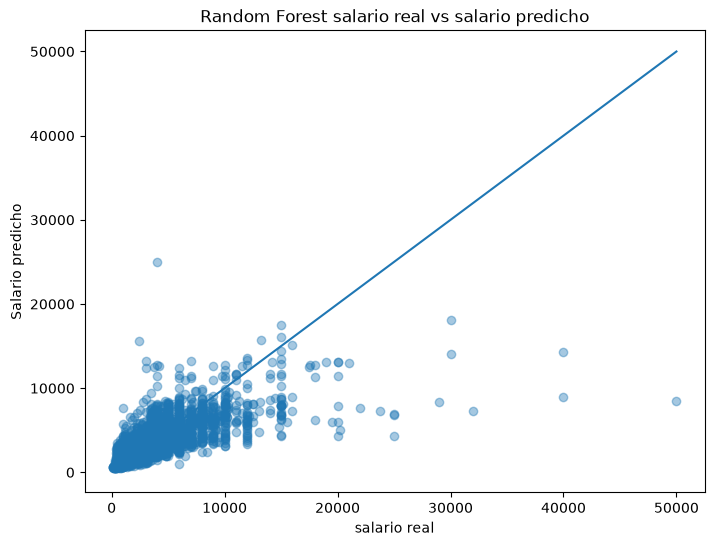

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize= (8 , 6))

plt.scatter( muestra_rf_pd["salario_mensual"],  muestra_rf_pd["prediction"], alpha= 0.4 )
min_val = min(muestra_rf_pd["salario_mensual"].min(), muestra_rf_pd["prediction"].min() )

max_val = max( muestra_rf_pd["salario_mensual"].max() , muestra_rf_pd["prediction"].max() )

plt.plot([min_val, max_val],  [min_val, max_val] )

plt.xlabel("salario real")
plt.ylabel("Salario predicho")
plt.title("Random Forest salario real vs salario predicho")
plt.show()

En la gráfica se observa que el modelo muestra un mejor ajuste en los salarios bajos y medios, donde más puntos se encuentra cerca de la línea de referencia.

Sin embargo, a medida que aumenta el salario real también aumenta la separación respecto a la línea ideal. En varios de los salarios más altos, las predicciones se encuentran considerablemente por debajo del valor real. Por ende, Random Forest tiene dificultades para representar los valores extremos.

## Residuos frente al salario predicho

Se analizan los residuos en función del salario predicho. La línea horizontal en cero representa ausencia de error.
Un residuo positivo indica que el modelo subestimó el salario, mientras que un residuo negativo indica que lo sobreestimó.

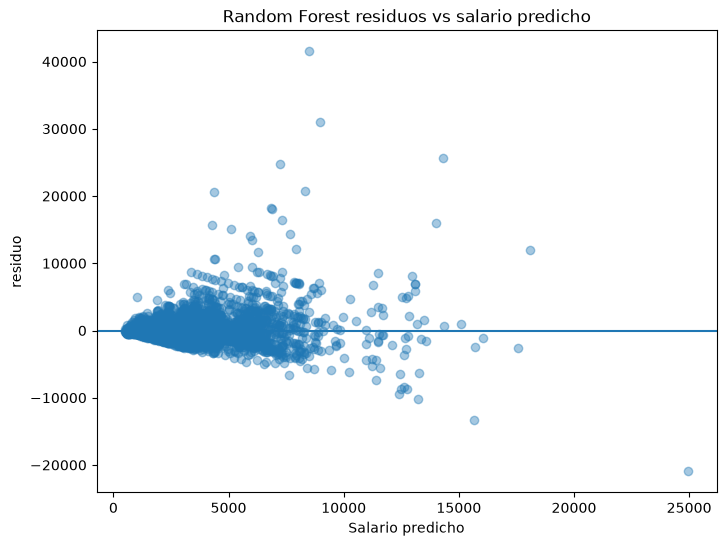

In [132]:
plt.figure(figsize=(8, 6))

plt.scatter( muestra_rf_pd["prediction"], muestra_rf_pd["residuo"], alpha = 0.4 )
plt.axhline(y=0)

plt.xlabel("Salario predicho")
plt.ylabel("residuo")
plt.title("Random Forest residuos vs salario predicho")
plt.show()

Los errores no mantienen la misma dispersión para todos los valores. En los salarios predichos más bajos, los residuos están alrededor de cero, mientras que la dispersión aumenta conforme aumenta el salario predicho.

También, para los residuos positivos de gran magnitud, esto se ve ebido a que el residuo se definió como salario real menos salario predicho, estos valores positivos indican casos en los que el modelo subestimó el salario real. Esto indica que los errores tienden a ser mayores en los salarios más altos.

## Error por nivel educativo

El MAE y el error medio para cada nivel educativo utilizando todos los registros del conjunto de prueba. El error medio indica la dirección general del error. 

In [134]:
tabla_nivel_rf = (
    pred_test_rf_full
    .groupBy("nivel_educativo")
    .agg( F.count("*").alias("n_observaciones"), F.round(F.avg("error_abs"), 2).alias("MAE") , F.round(F.avg("residuo"), 2).alias("error_medio")
    )
    .orderBy("nivel_educativo")
)

tabla_nivel_rf.show(truncate = False)

+---------------+---------------+--------+-----------+
|nivel_educativo|n_observaciones|MAE     |error_medio|
+---------------+---------------+--------+-----------+
|0              |1016           |652.87  |-40.37     |
|1              |80             |613.19  |-106.17    |
|2              |3957           |756.29  |40.12      |
|3              |2164           |824.37  |130.36     |
|4              |4117           |1021.63 |118.24     |
|5              |1729           |2280.11 |306.89     |
|6              |183            |4574.09 |-314.31    |
|7              |12             |10825.06|5378.87    |
+---------------+---------------+--------+-----------+



Para los niveles con mayor cantidad de observaciones, el MAE se mantiene relativamente menor, aunque aumenta en algunos niveles educativos superiores.

Los niveles 5, 6 y 7 tienen los mayores valores de MAE. Los niveles 6 y 7 contienen únicamente 183 y 12 registros, por lo que sus resultados deben interpretarse con precaución.

El nivel 7 presenta además un error medio positivo elevado, esto indica tendencia a subestimar los salarios de este grupo. En otros niveles, el error medio se encuentra más cerca de cero y alterna entre pequeñas tendencias de subestimación y sobreestimación.

## Error por dominio

Se realiza el mismo análisis agrupando los registros según el dominio. 

In [135]:
tabla_dominio_rf = (
    pred_test_rf_full
    .groupBy("dominio")
    .agg(
        F.count("*").alias("n_observaciones"),
        F.round(F.avg("error_abs"), 2).alias("MAE"),
        F.round(F.avg("residuo"), 2).alias("error_medio")
    )
    .orderBy("dominio")
)

tabla_dominio_rf.show(truncate = False)

[Stage 710:>                                                        (0 + 1) / 1]

+-------+---------------+-------+-----------+
|dominio|n_observaciones|MAE    |error_medio|
+-------+---------------+-------+-----------+
|1      |5632           |1317.36|168.99     |
|2      |4846           |1039.05|91.03      |
|3      |2780           |773.26 |8.24       |
+-------+---------------+-------+-----------+



El dominio 1 tiene el mayor MAE, con Q1,317.36, seguido del dominio 2 con Q1,039.05 y el dominio 3 con Q773.26.

Los tres dominios tienen un error medio positivo, esto muestra tendencia a subestimar los salarios. La tendencia es menor en el dominio 3, donde el error medio es de Q8.24 y se encuentra más cerca de cero.

## Análisis por percentiles de salario

Para analizar cómo cambia el comportamiento del modelo según el nivel salarial, calculamos los percentiles 25, 50, 75, 90 y 95 del salario mensual.

In [137]:
percentiles = pred_test_rf_full.approxQuantile( "salario_mensual", [0.25, 0.50, 0.75, 0.90, 0.95], 0.001 )

p25, p50, p75, p90, p95 = percentiles

print("P25:", p25)
print("P50:", p50)
print("P75:", p75)
print("P90:", p90)
print("P95:", p95)

P25: 2000.0
P50: 3200.0
P75: 4066.0
P90: 6000.0
P95: 8000.0


In [139]:
pred_test_rf_percentiles = (
    pred_test_rf_full
    .withColumn(
        "grupo_salario",
        F.when(F.col("salario_mensual") <= p25, "Hasta P25")
        .when(F.col("salario_mensual") <= p50, "P25 - P50")
        .when(F.col("salario_mensual") <= p75, "P50 - P75")
        .when(F.col("salario_mensual") <= p90, "P75 - P90")
        .when(F.col("salario_mensual") <= p95, "P90 - P95")
        .otherwise("Mayor a P95")
    )
)

In [140]:
tabla_percentiles_rf = (
    pred_test_rf_percentiles
    .groupBy("grupo_salario")
    .agg(
        F.count("*").alias("n_observaciones"),
        F.round(F.avg("error_abs"), 2).alias("MAE"),
        F.round(F.avg("residuo"), 2).alias("error_medio")
    )
)

tabla_percentiles_rf.show(truncate=False)

+-------------+---------------+-------+-----------+
|grupo_salario|n_observaciones|MAE    |error_medio|
+-------------+---------------+-------+-----------+
|P50 - P75    |3188           |740.24 |-44.37     |
|P90 - P95    |608            |1971.88|1517.9     |
|P25 - P50    |2715           |686.47 |-163.26    |
|Hasta P25    |4032           |851.83 |-763.85    |
|Mayor a P95  |643            |5130.34|4884.57    |
|P75 - P90    |2072           |1181.64|490.66     |
+-------------+---------------+-------+-----------+



Para los salarios ubicados hasta el percentil 25, el error medio es negativo, lo que indica una tendencia a sobreestimar los salarios más bajos. Esta tendencia disminuye en los grupos intermedios, donde el error medio se encuentra más cerca de cero.

A partir del rango entre los percentiles 75 y 90, el error medio pasa a ser positivo, indicando una tendencia a subestimar. Esta tendencia aumenta considerablemente en los salarios más altos. Para los registros superiores al percentil 95, el MAE alcanza aproximadamente Q5,130.34 y el error medio es de Q4,884.57.

Los resultados muestran que el modelo presenta una tendencia a subestimar los salarios altos, esto se ve más para los salarios superiores a Q8,000.

## Discusión de los resultados

Random Forest presentó un mejor comportamiento para los salarios bajos y medios, mientras que los errores aumentaron conforme se analizaron salarios más altos. Las gráficas y el análisis por percentiles muestran un patrón consistente. Los salarios más bajos presentan cierta tendencia a ser sobreestimados, mientras que en los rangos intermedios el error medio se acerca a cero. En los percentiles superiores aparece una tendencia creciente a la subestimación, esto se ve más en los salarios mayores al percentil 95.

También hay diferencias entre niveles educativos y dominios. Algunos niveles educativos tienen errores considerablemente mayores. Entre los dominios, el dominio 1 presentó el mayor MAE y el dominio 3 el menor.

Aunque Random Forest tiene un buen desempeño y mejores métricas que la regresión lineal, su precisión no es uniforme para todos los salarios. La principal dificultad del modelo se encuentra en la predicción de los salarios más altos y menos frecuentes.